In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hmm_utils import (
    assign_regimes,
    add_hmm_features,
    automatic_hmm_feature_selection,
    extract_best_hmm_feature_subset,
    fit_best_hmm_from_results,
    summarize_hmm_results,
)

c:\Users\SchweSe\AppData\Local\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("deribit_enriched_data.csv")
df['timestamp']= pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

df.head(3)

,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,...,std_72h_sq_return_index_price,ATR_24h_spot,ATR_72h_spot,ATR_24h_spot_norm,ATR_72h_spot_norm,ATR_24h_perp,ATR_72h_perp,ATR_24h_perp_norm,ATR_72h_perp_norm,high_vol
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
# =========================================================
# FINAL optimized HMM feature set (non-redundant + stable)
# =========================================================

# --- Activity (level + shock) ---
basic_feature = [
    "volume_perp",
    "volume_spot",
    "price_prep"
]

activity_features = [
    "log_volume_perp",         # core activity level
    "ma_24h_volume_perp",       # activity shock
]

# --- Market structure ---
structure_features = [
    "volume_perp_to_spot",     # derivatives dominance
]

# --- Volatility (ONE robust proxy) ---
volatility_features = [
    "std_72h_sq_return_close_perp",  # smoother regime signal
]

# --- Price dynamics (minimal) ---
price_features = [
    "return_24h_close_perp",   # trend
    "z_24h_close_perp",        # deviation
]

# --- Leverage / stress (MOST IMPORTANT BLOCK) ---
leverage_features = [
    "cost_x_volume_perp",      # core stress feature (MUST HAVE)
    "z_24h_cost_perp",         # abnormal funding / cost
]

# --- Funding (optional but useful) ---
funding_features = [
    "interest_8h",
    "interest_1h",
]

# --- Combine ---
all_candidates = (
    basic_feature +
    activity_features +
    structure_features +
    volatility_features +
    price_features +
    leverage_features +
    funding_features
)

# --- Keep only existing ---
hmm_candidate_features = [f for f in all_candidates if f in df.columns]

print(f"Using {len(hmm_candidate_features)} candidate features")
print(hmm_candidate_features)

Using 5 candidate features
['volume_perp', 'volume_spot', 'std_72h_sq_return_close_perp', 'interest_8h', 'interest_1h']


In [ ]:
results = automatic_hmm_feature_selection(
    df=df,
    candidate_features=hmm_candidate_features,
    subset_min_size=2,
    subset_max_size=4,
    n_states_list=[3],
    min_state_fraction_threshold=0.05,
    top_k=20
)


HMM feature search:   8%|▊         | 2/25 [00:04<00:48,  2.09s/fit]

In [ ]:
summary = summarize_hmm_results(results, top_n=10, stringify_features=True)
best = extract_best_hmm_feature_subset(results)

hmm, scaler, best_features, best_n_states = fit_best_hmm_from_results(
    df=df,
    results_df=results
)
df_hmm = add_hmm_features(df, hmm, scaler, best_features)
df_full = pd.concat([df, df_hmm], axis=1)

price_col = "close_perp"   # change if needed

# auto-detect HMM columns
state_col = [c for c in df_full.columns if "state" in c.lower()][0]
prob_cols = [c for c in df_full.columns if "prob" in c.lower()]


In [ ]:
summary.to_csv("hmm_feature_selection_summary.csv", index=False)
summary

,feature_cols,n_states,n_features,n_obs_used,eligible,selection_score,train_loglik,min_state_fraction,avg_self_transition,median_run_length,avg_entropy
0,"interest_8h, interest_1h",3,2,12283,True,-3900.977211,-3900.977211,0.216885,0.864094,4.0,0.078232
1,"volume_perp, volume_spot",3,2,12283,True,-13481.819168,-13481.819168,0.143206,0.701107,2.0,0.187838
2,"volume_perp, interest_1h",3,2,12283,True,-13704.243870,-13704.243870,0.261825,0.808320,3.0,0.118235
3,"volume_perp, std_72h_sq_return_close_perp",3,2,12211,True,-14403.454906,-14403.454906,0.206371,0.948261,7.0,0.064252
4,"volume_spot, interest_1h",3,2,12283,True,-14550.188146,-14550.188146,0.258976,0.805024,3.0,0.116944
5,"volume_spot, std_72h_sq_return_close_perp",3,2,12211,True,-15694.197050,-15694.197050,0.189583,0.941887,7.0,0.071026
6,"volume_perp, interest_8h",3,2,12283,True,-16483.174113,-16483.174113,0.205406,0.908291,8.0,0.121172
7,"std_72h_sq_return_close_perp, interest_1h",3,2,12211,True,-16759.103212,-16759.103212,0.233806,0.839519,3.0,0.117415
8,"volume_spot, interest_8h",3,2,12283,True,-17047.601889,-17047.601889,0.271676,0.912209,8.0,0.107790
9,"volume_perp, interest_8h, interest_1h",3,3,12283,True,-17908.024026,-17908.024026,0.264431,0.870234,4.0,0.090755


In [ ]:
state_counts = df_full["hmm_state"].value_counts(normalize=True).sort_index()
print(state_counts)

hmm_state
0.0    0.405627
1.0    0.318875
2.0    0.275498
Name: proportion, dtype: float64


In [ ]:
df_regimes_stats = df_full.groupby(state_col).agg({
    "close_perp": ["mean"],
    "abs_return_close_perp": ["mean"],
    "volume_perp": ["mean"]
})
df_regimes_stats

,close_perp,abs_return_close_perp,volume_perp
,mean,mean,mean
hmm_state,,,
0.0,81740.848627,0.003364,354.550090
1.0,81425.601026,0.003624,461.402018
2.0,82553.430230,0.003276,286.989037


In [ ]:
regime_labels, regime_colors = assign_regimes(df_regimes_stats)

print(regime_labels)
print(regime_colors)

NameError: name 'assign_regimes' is not defined

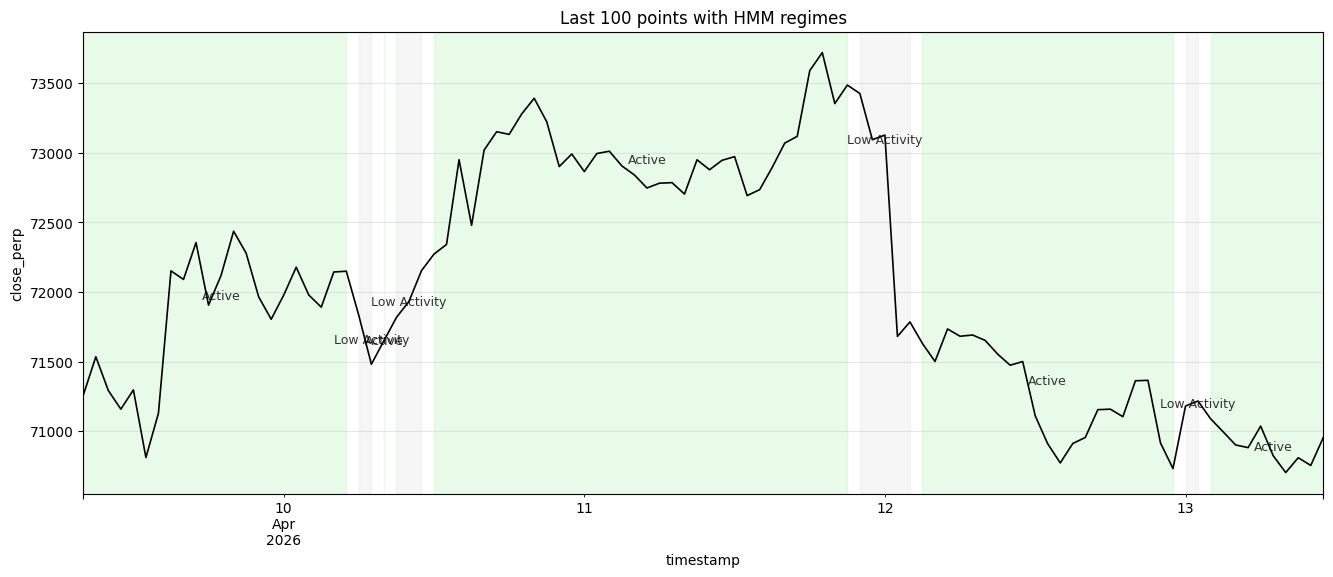

In [ ]:
# =========================
# CONFIG
# =========================
N = 100

# =========================
# DATA
# =========================
plot_df = df_full[[price_col, state_col]].dropna().tail(N)

ax = plot_df[price_col].plot(
    figsize=(16, 6),
    lw=1.2,
    color="black",
    title=f"Last {N} points with HMM regimes"
)

state_series = plot_df[state_col]
change_points = state_series.ne(state_series.shift()).cumsum()

# =========================
# PLOT REGIMES + LABELS
# =========================
for _, block in plot_df.groupby(change_points):
    state = int(block[state_col].iloc[0])
    
    x0 = block.index[0]
    x1 = block.index[-1]

    label = regime_labels.get(state, f"State {state}")
    color = regime_colors.get(state, "grey")

    # background
    ax.axvspan(x0, x1, alpha=0.2, color=color)

    # position label in the middle of segment
    x_mid = block.index[len(block) // 2]
    y_mid = block[price_col].median()

    ax.text(
        x_mid,
        y_mid,
        label,
        fontsize=9,
        ha="center",
        va="center",
        alpha=0.8
    )

ax.set_ylabel(price_col)
ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
states = df_full["hmm_state"].dropna().values

runs = []
current = 1

for i in range(1, len(states)):
    if states[i] == states[i-1]:
        current += 1
    else:
        runs.append(current)
        current = 1
runs.append(current)

print("Mean run length:", np.mean(runs))
print("Median run length:", np.median(runs))

Mean run length: 7.965758754863813
Median run length: 4.0


In [ ]:
trans_mat = pd.DataFrame(
    hmm.transmat_,
    index=[f"from_{i}" for i in range(best_n_states)],
    columns=[f"to_{i}" for i in range(best_n_states)]
)

print(trans_mat)

            to_0          to_1          to_2
from_0  0.847052  3.676785e-02  1.161804e-01
from_1  0.037743  9.622571e-01  5.564634e-91
from_2  0.217026  3.958466e-71  7.829744e-01


In [ ]:
print("Avg max prob:", df_full["hmm_max_prob"].mean())
print("Avg entropy:", df_full["hmm_entropy"].mean())

Avg max prob: 0.9672343026935075
Avg entropy: 0.07989843202329343


In [ ]:
state_summary = df_full.groupby("hmm_state")[best_features].mean()
print(state_summary)

           interest_8h   interest_1h
hmm_state                           
0.0           0.000027  3.386724e-06
1.0           0.000180  2.267421e-05
2.0           0.000002  2.068079e-08


<Axes: title={'center': 'State Distribution'}, xlabel='hmm_state'>

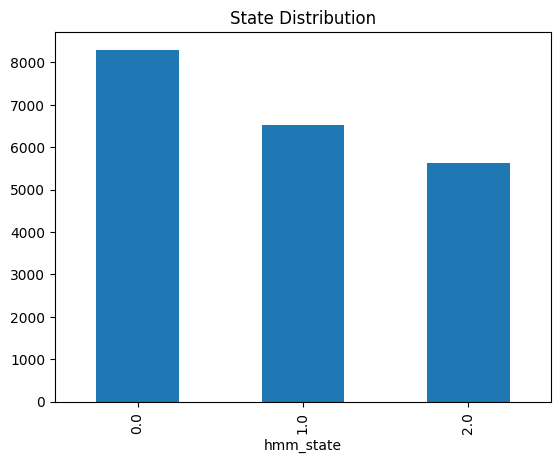

In [ ]:
df_full["hmm_state"].value_counts().plot(kind="bar", title="State Distribution")

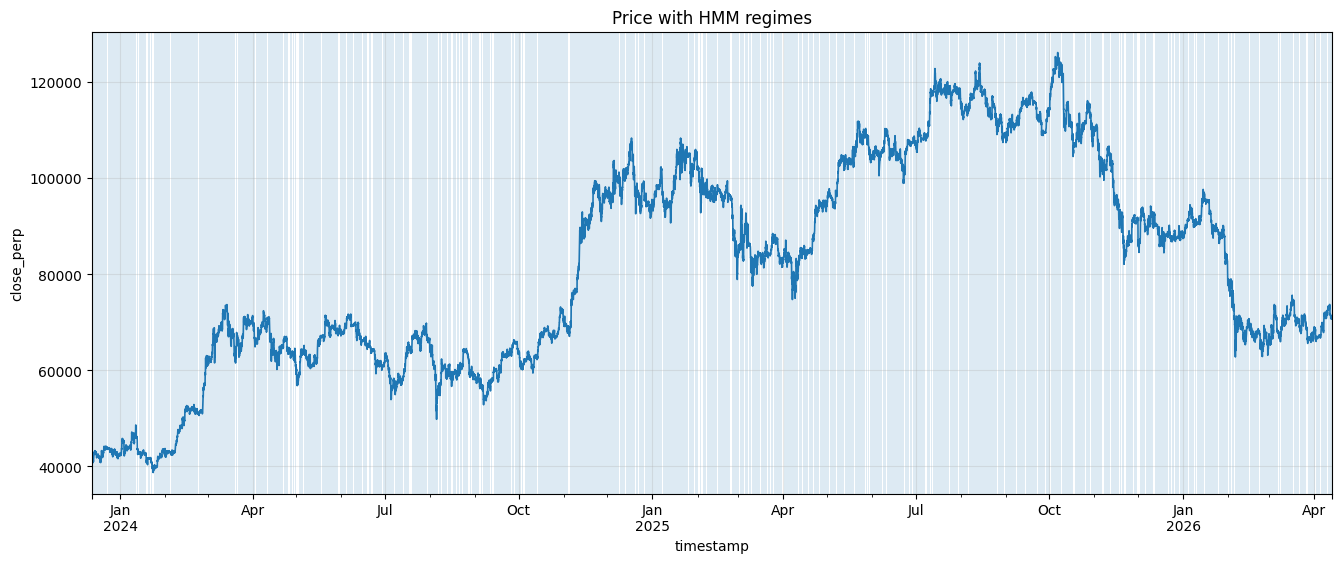

In [ ]:
plot_df = df_full[[price_col, state_col]].dropna().copy()

ax = plot_df[price_col].plot(figsize=(16, 6), lw=1.2, title="Price with HMM regimes")

state_series = plot_df[state_col]
change_points = state_series.ne(state_series.shift()).cumsum()

for _, block in plot_df.groupby(change_points):
    x0 = block.index[0]
    x1 = block.index[-1]
    ax.axvspan(x0, x1, alpha=0.15)

ax.set_ylabel(price_col)
ax.grid(True, alpha=0.3)

plt.show()

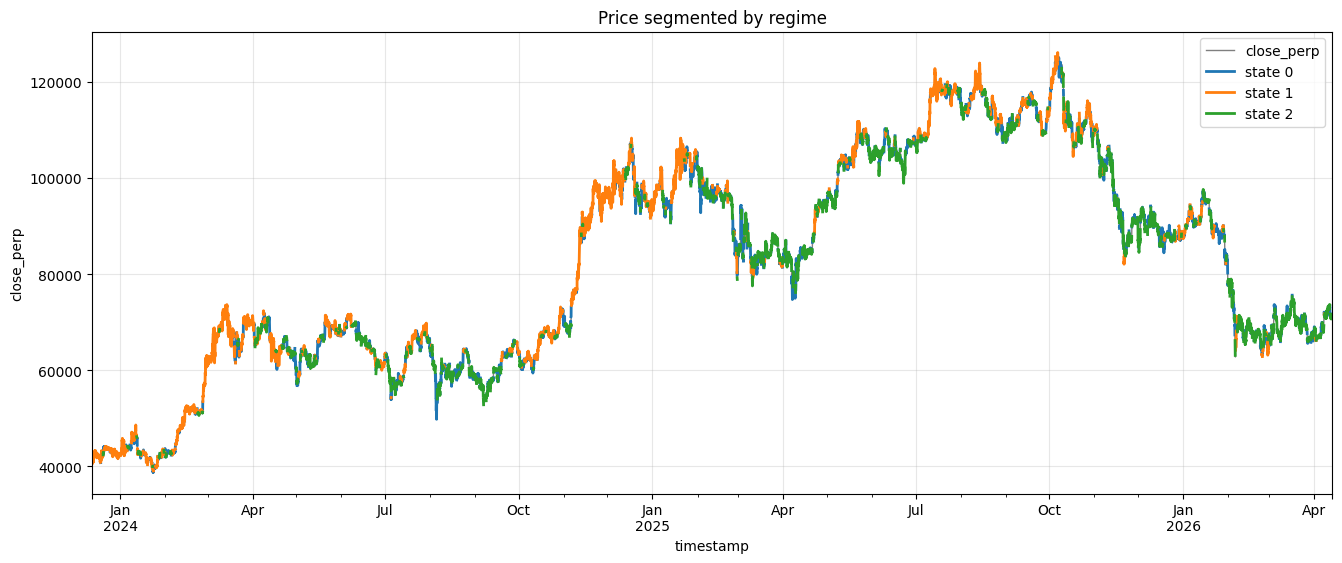

In [ ]:
plot_df = df_full[[price_col, state_col]].dropna().copy()

ax = plot_df[price_col].plot(figsize=(16, 6), lw=1.0, color="black", alpha=0.5, title="Price segmented by regime")

states = sorted(plot_df[state_col].unique())

for s in states:
    plot_df[price_col].where(plot_df[state_col] == s).plot(
        ax=ax, lw=2, label=f"state {int(s)}"
    )

ax.set_ylabel(price_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

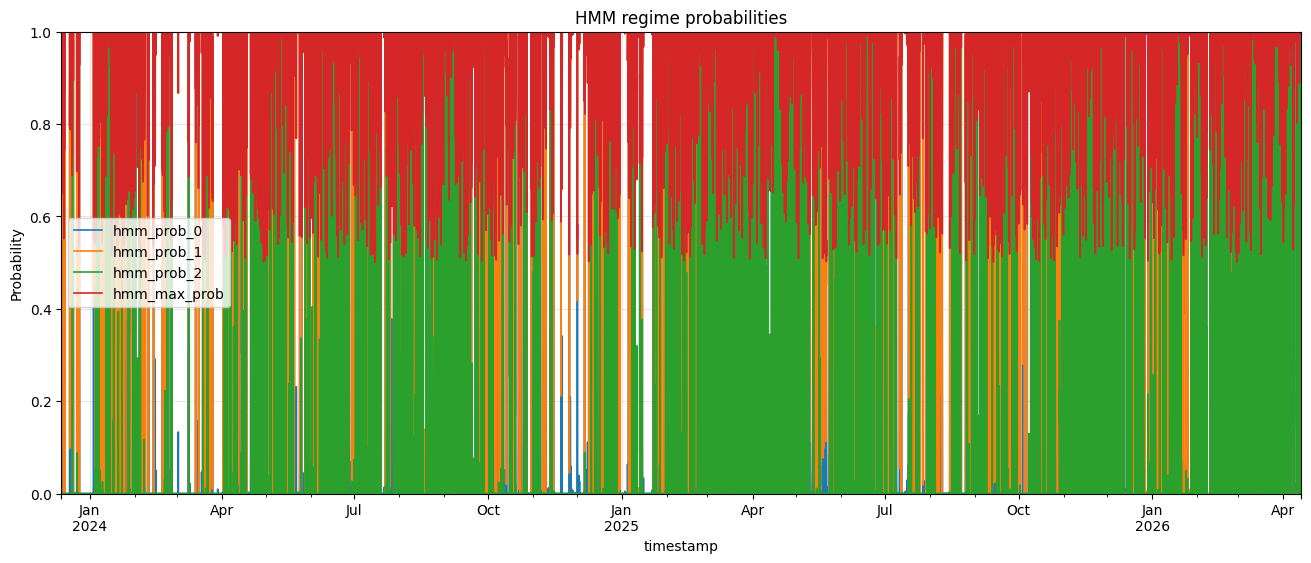

In [ ]:
plot_df = df_full[prob_cols].dropna().copy()

ax = plot_df.plot(figsize=(16, 6), lw=1.2, title="HMM regime probabilities")

ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.show()